In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("clean_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 12000
Columns: 18


,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount,Revenue,Cost,Profit,City,Customer_Segment,Payment_Method,Order_Year,Order_Month,Order_Month_Name,Profit_Margin
0,ORD09130,2024-03-23,CUST02722,Blender,Home Appliances,8.00,67.17,0.05,510.49,414.00,96.49,Chennai,Home Office,Credit Card,2024,3,March,18.90
1,ORD04526,2023-06-03,CUST00659,Jacket,Fashion,1.00,152.46,0.25,114.34,91.14,23.20,Chennai,Corporate,Cash,2023,6,June,20.29
2,ORD01745,2023-06-18,CUST00162,Headphones,Electronics,6.00,183.00,0.20,878.40,980.40,-102.00,Bhubaneswar,Consumer,Debit Card,2023,6,June,-11.61
3,ORD06248,2025-06-16,CUST01141,Smartphone,Electronics,4.00,810.80,0.00,3315.43,2710.18,605.25,Bangalore,Corporate,Debit Card,2025,6,June,18.26
4,ORD07863,2023-02-11,CUST03469,Shoes,Fashion,1.00,134.93,0.00,134.93,85.82,49.11,Bhubaneswar,Consumer,Credit Card,2023,2,February,36.40


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(12000, 18)

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount', 'Revenue', 'Cost', 'Profit', 'City', 'Customer_Segment', 'Payment_Method', 'Order_Year', 'Order_Month', 'Order_Month_Name', 'Profit_Margin']

Data Types:
Order_ID             object
Order_Date           object
Customer_ID          object
Product              object
Category             object
Quantity            float64
Unit_Price          float64
Discount            float64
Revenue             float64
Cost                float64
Profit              float64
City                 object
Customer_Segment     object
Payment_Method       object
Order_Year            int64
Order_Month           int64
Order_Month_Name     object
Profit_Margin       float64
dtype: object

Missing Values:
Order_ID            0
Order_Date          0
Customer_ID         0
Product             0
Category            0
Quantity            0
Unit_Price          0
Discount    

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

summary_statistics = df[numeric_cols].describe().T

summary_statistics["median"] = df[numeric_cols].median()

summary_statistics = summary_statistics[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]

summary_statistics

,count,mean,median,std,min,25%,50%,75%,max
Quantity,12000.00,4.51,4.00,2.34,1.00,2.00,4.00,7.00,14.50
Unit_Price,12000.00,284.21,200.86,235.85,11.91,105.48,200.86,387.61,810.80
Discount,12000.00,0.13,0.15,0.09,0.00,0.05,0.15,0.20,0.25
Revenue,12000.00,1067.36,680.81,1003.69,14.43,308.34,680.81,1511.17,3315.43
Cost,12000.00,875.67,564.36,816.73,10.62,256.33,564.36,1237.87,2710.18
Profit,12000.00,191.70,92.29,268.33,-527.96,19.27,92.29,293.84,3275.63
Order_Year,12000.00,2024.00,2024.00,0.82,2023.00,2023.00,2024.00,2025.00,2025.00
Order_Month,12000.00,6.52,7.00,3.46,1.00,3.00,7.00,10.00,12.00
Profit_Margin,12000.00,15.83,18.26,14.66,-26.97,6.56,18.26,26.00,98.80


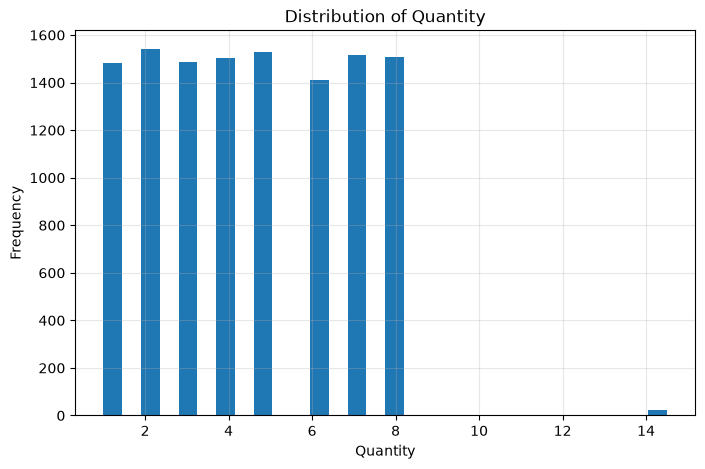

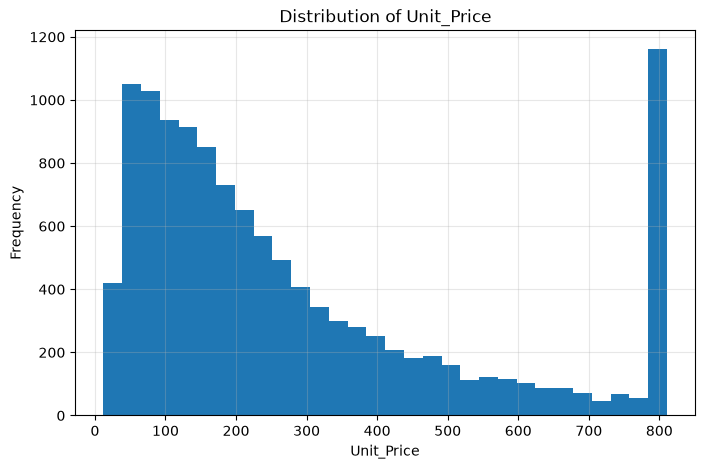

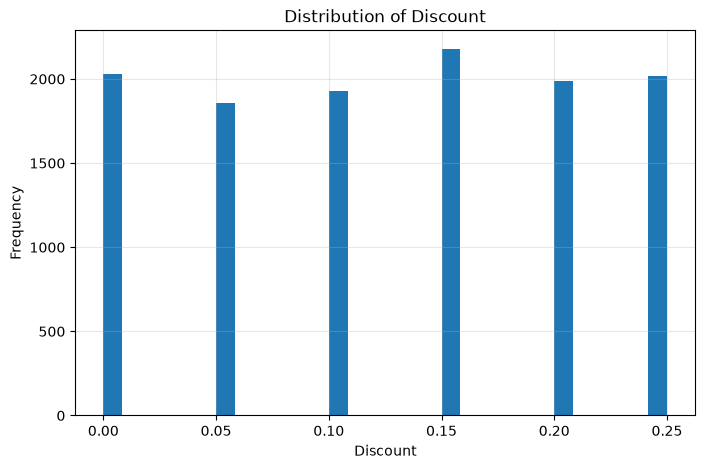

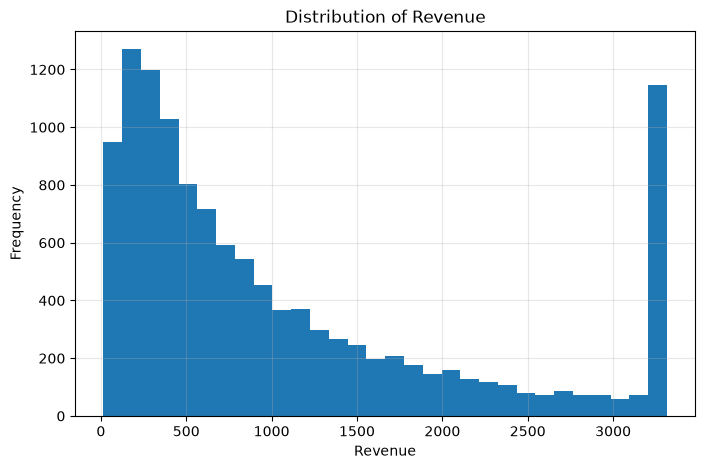

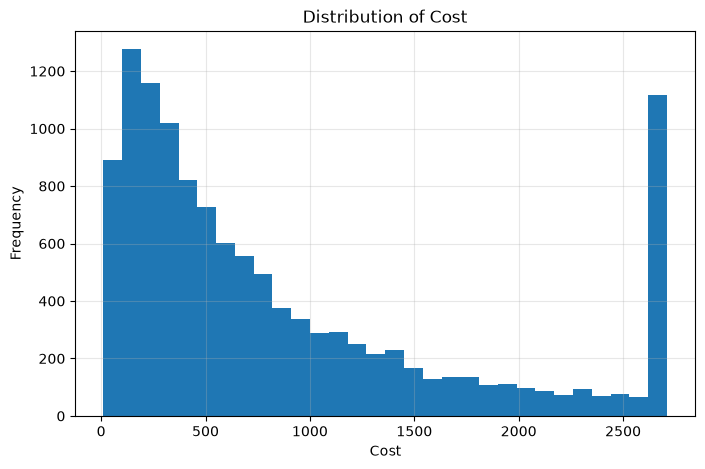

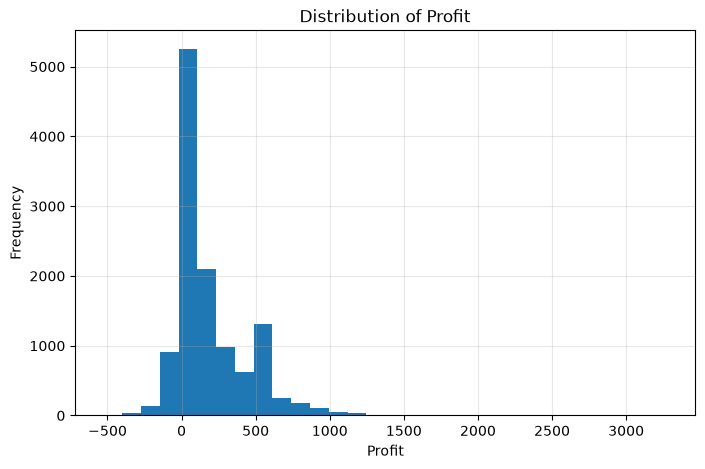

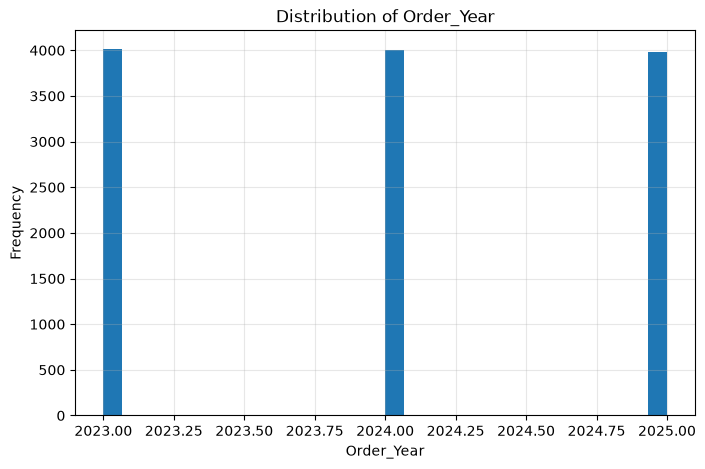

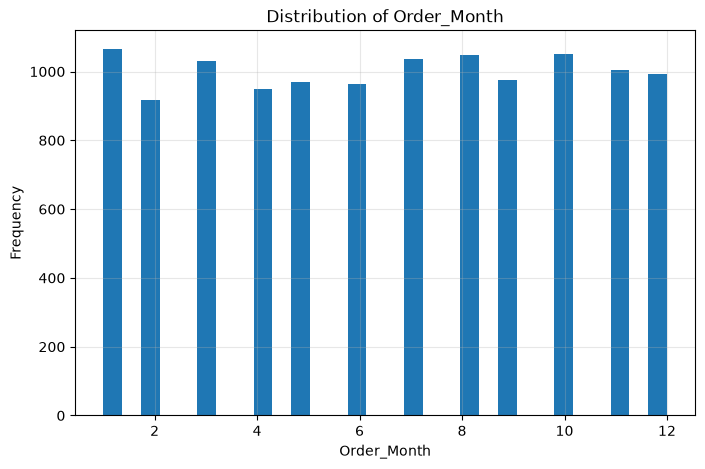

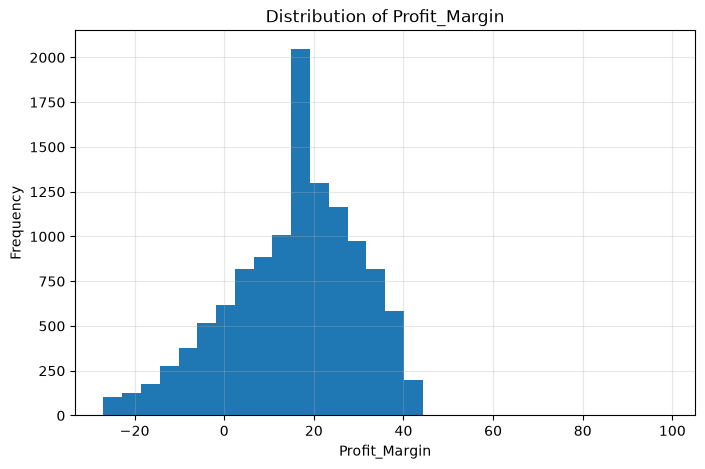

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

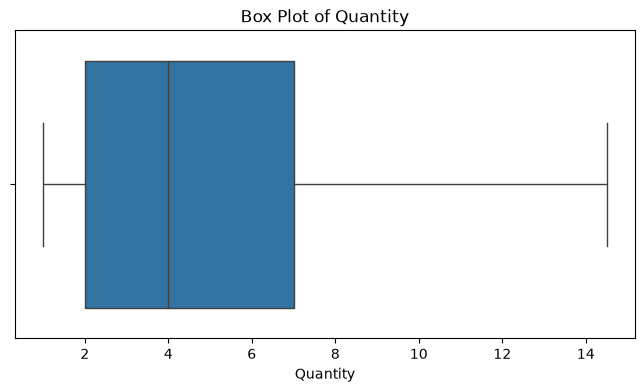

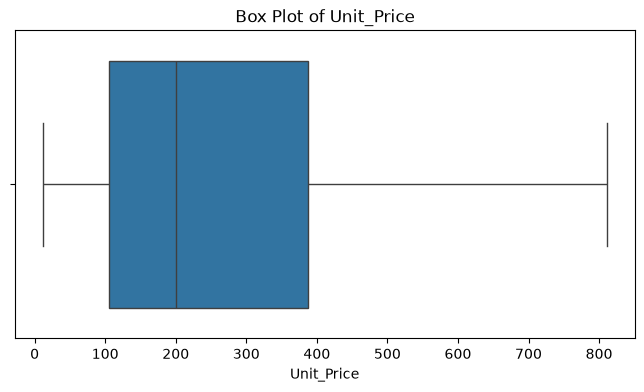

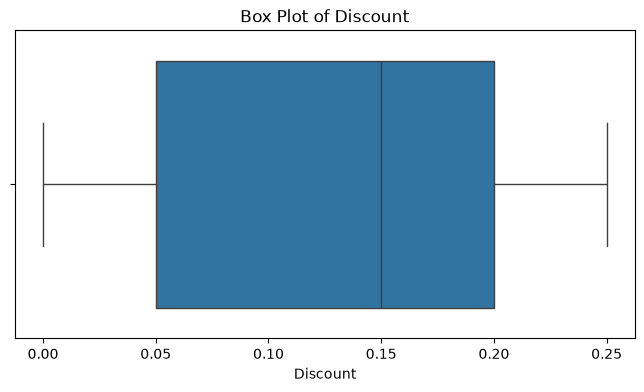

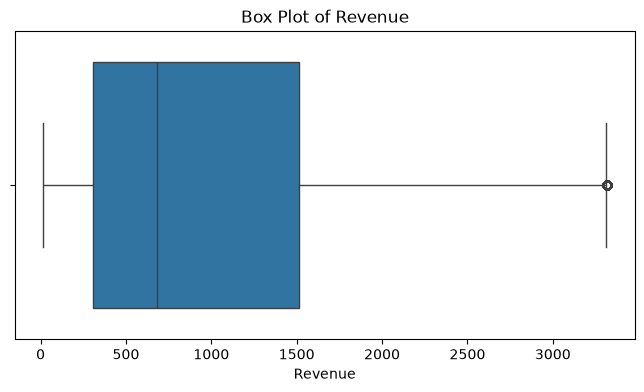

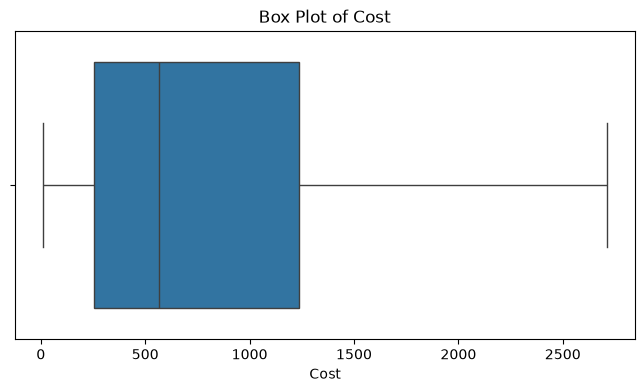

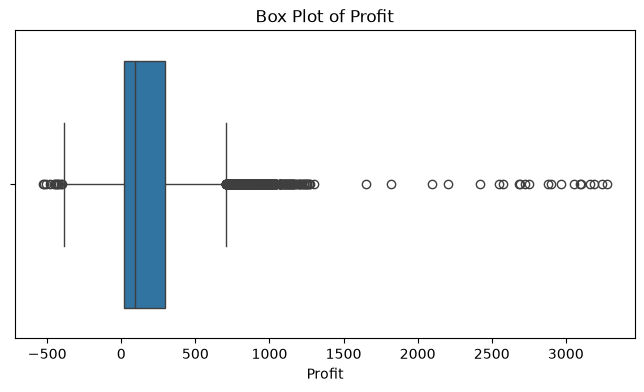

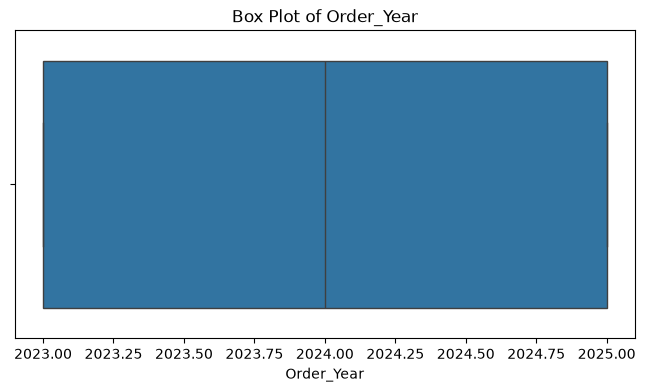

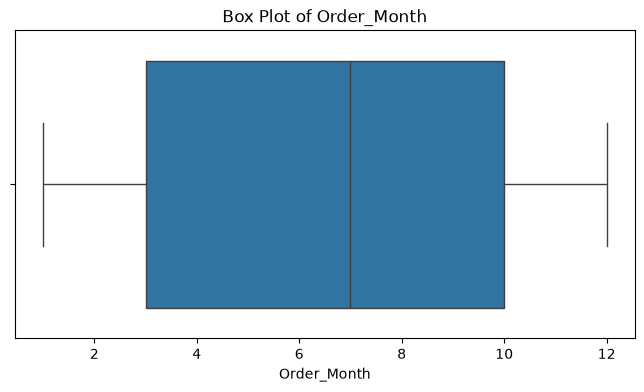

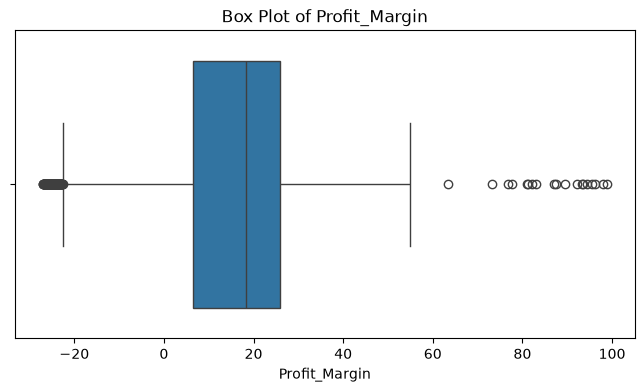

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.show()

In [9]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Quantity,2.00,7.00,5.00,-5.50,14.50,0
1,Unit_Price,105.48,387.61,282.13,-317.71,810.80,0
2,Discount,0.05,0.20,0.15,-0.18,0.43,0
3,Revenue,308.34,1511.17,1202.84,-1495.91,3315.43,1090
4,Cost,256.33,1237.87,981.54,-1215.98,2710.18,0
5,Profit,19.27,293.84,274.58,-392.60,705.71,453
6,Order_Year,2023.00,2025.00,2.00,2020.00,2028.00,0
7,Order_Month,3.00,10.00,7.00,-7.50,20.50,0
8,Profit_Margin,6.56,26.00,19.45,-22.61,55.17,127


In [10]:
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Quantity,Unit_Price,Discount,Revenue,Cost,Profit,Order_Year,Order_Month,Profit_Margin
Quantity,1.00,0.01,0.00,0.47,0.46,0.36,-0.01,-0.03,0.03
Unit_Price,0.01,1.00,-0.01,0.82,0.81,0.58,-0.00,0.01,0.11
Discount,0.00,-0.01,1.00,-0.08,-0.01,-0.27,-0.00,0.01,-0.51
Revenue,0.47,0.82,-0.08,1.00,0.98,0.77,-0.02,-0.00,0.15
Cost,0.46,0.81,-0.01,0.98,1.00,0.61,-0.02,-0.00,0.00
Profit,0.36,0.58,-0.27,0.77,0.61,1.00,-0.01,-0.01,0.58
Order_Year,-0.01,-0.00,-0.00,-0.02,-0.02,-0.01,1.00,0.01,0.00
Order_Month,-0.03,0.01,0.01,-0.00,-0.00,-0.01,0.01,1.00,-0.01
Profit_Margin,0.03,0.11,-0.51,0.15,0.00,0.58,0.00,-0.01,1.00


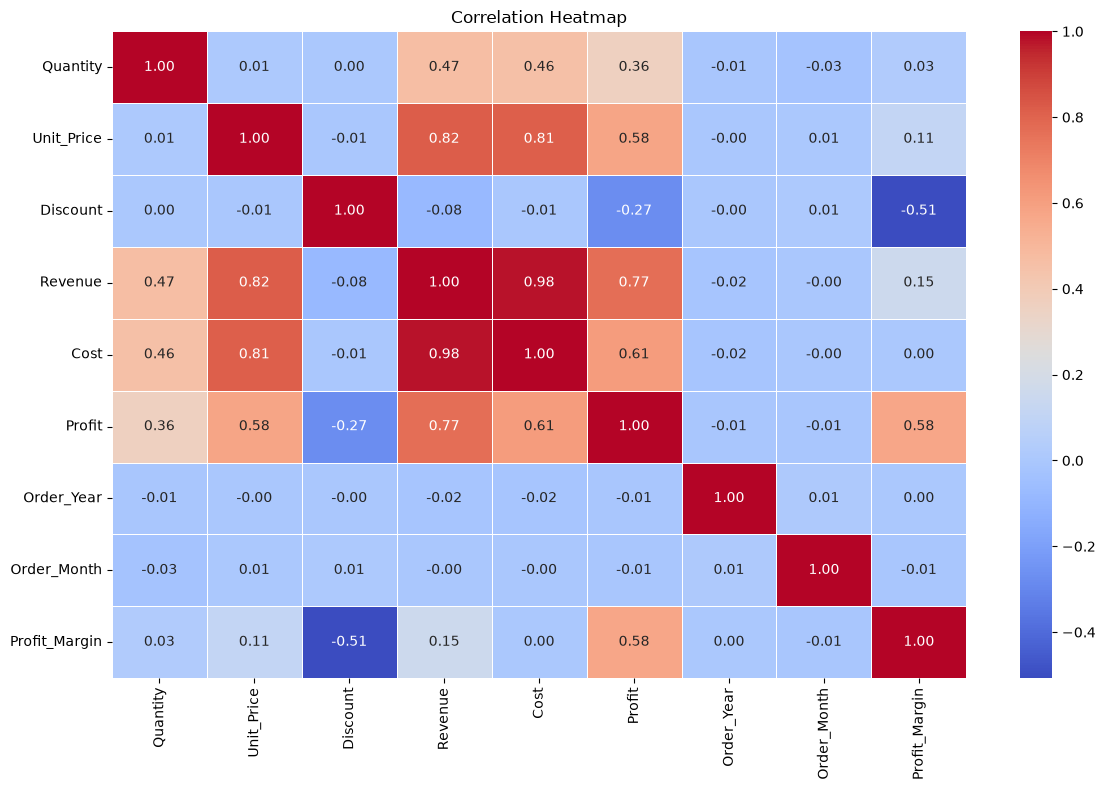

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [12]:
corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    (corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1))
]

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

corr_pairs.head(10)

Revenue     Cost         0.98
Cost        Revenue      0.98
Revenue     Unit_Price   0.82
Unit_Price  Revenue      0.82
            Cost         0.81
Cost        Unit_Price   0.81
Profit      Revenue      0.77
Revenue     Profit       0.77
Profit      Cost         0.61
Cost        Profit       0.61
dtype: float64

In [13]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount', 'Revenue', 'Cost', 'Profit', 'City', 'Customer_Segment', 'Payment_Method', 'Order_Year', 'Order_Month', 'Order_Month_Name', 'Profit_Margin']


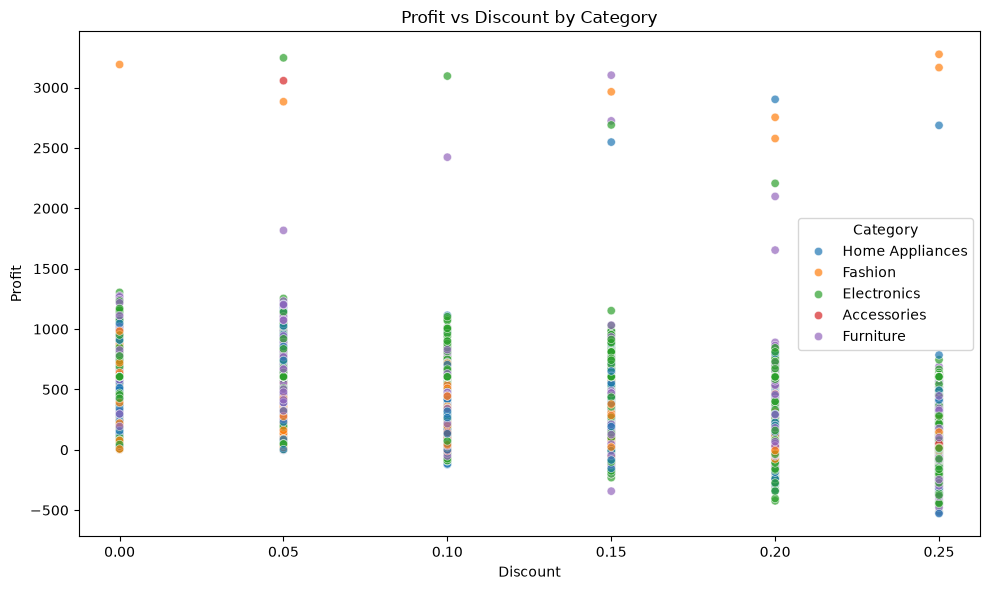

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.7
)

plt.title("Profit vs Discount by Category")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

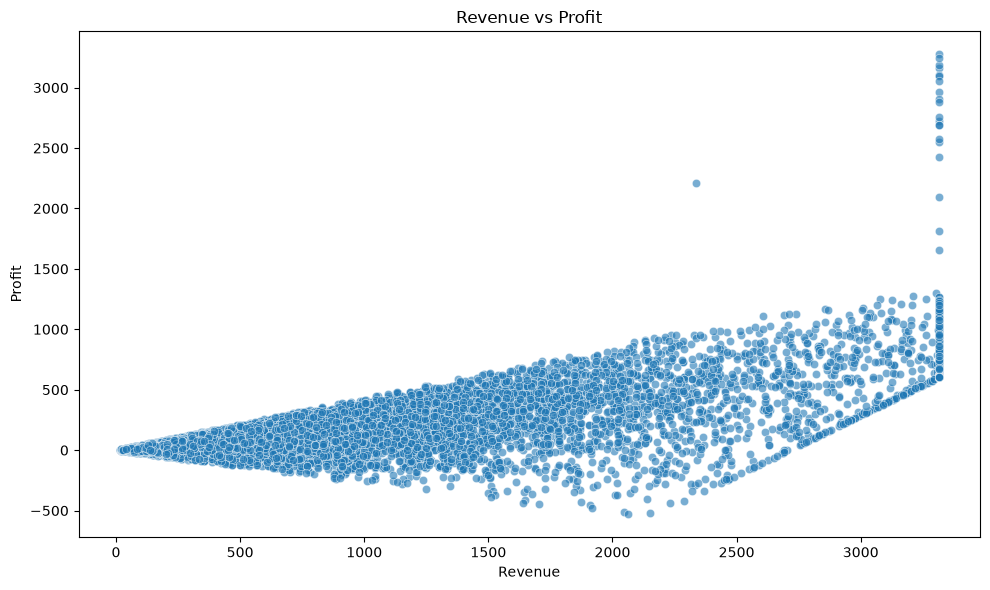

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Revenue",
    y="Profit",
    alpha=0.6
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [16]:
discount_profit_corr = df["Discount"].corr(df["Profit"])

print("Correlation between Discount and Profit:",
      round(discount_profit_corr, 3))

Correlation between Discount and Profit: -0.274


In [17]:
r, p_value = stats.pearsonr(
    df["Discount"].dropna(),
    df["Profit"].loc[df["Discount"].notna()]
)

print("Correlation:", round(r, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: The relationship is statistically significant.")
else:
    print("Fail to reject H0: The relationship is not statistically significant.")

Correlation: -0.274
P-value: 1.8786618048676318e-205
Reject H0: The relationship is statistically significant.


In [19]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount', 'Revenue', 'Cost', 'Profit', 'City', 'Customer_Segment', 'Payment_Method', 'Order_Year', 'Order_Month', 'Order_Month_Name', 'Profit_Margin']


In [20]:
# Revenue vs Profit

revenue_profit = df[["Revenue", "Profit"]].dropna()

r, p_value = stats.pearsonr(
    revenue_profit["Revenue"],
    revenue_profit["Profit"]
)

print("Correlation between Revenue and Profit:", round(r, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Revenue and Profit have a statistically significant relationship.")
else:
    print("Fail to reject H0: Revenue and Profit do not have a statistically significant relationship.")

Correlation between Revenue and Profit: 0.766
P-value: 0.0
Reject H0: Revenue and Profit have a statistically significant relationship.


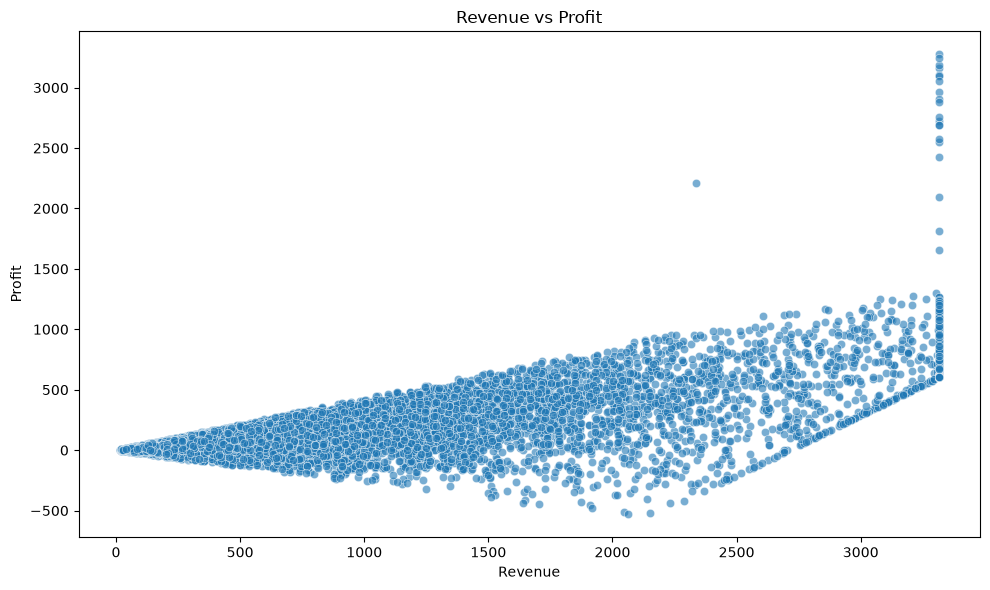

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Revenue",
    y="Profit",
    alpha=0.6
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [22]:
groups = [
    group["Profit"].dropna()
    for name, group in df.groupby("Category")
]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", round(f_stat, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Profit differs significantly across categories.")
else:
    print("Fail to reject H0: No statistically significant difference detected.")

F-statistic: 275.805
P-value: 3.372550814431583e-227
Reject H0: Profit differs significantly across categories.
